# Data preparation

A study assessing what aspects of democratic structures and movements are implicitly assumed in or are consistent with the narratives of the AR6 scenarios.

In [30]:
import os
import pyam
import warnings
import geopandas
import geodatasets
import ast
import string

import pandas as pd
import seaborn as sns
import numpy as np
import scipy.stats as stats

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

warnings.simplefilter(action='ignore', category=FutureWarning)
from IPython.display import display, HTML
from textwrap import wrap

In [31]:
sns.set_style("whitegrid")
sns.set_context("notebook")
plt.rc("axes.spines", top=False, right=False, left=False, bottom=False)

## Globals

In [32]:
map_3035 = geopandas.read_file('data/maps/CNTR_RG_20M_2024_3035.gpkg')
map_3035 = map_3035.rename({'NAME_ENGL':'region'},axis=1)

In [33]:
map_r10 = geopandas.read_file('data/maps/r10_regions.geojson')
map_r10 = map_r10.rename({'I_REGION':'region'},axis=1)

In [34]:
map_4326 = geopandas.read_file('data/maps/CNTR_RG_20M_2024_4326.gpkg')
map_4326 = map_4326.rename({'NAME_ENGL':'region'},axis=1)

In [35]:
EU27 = ['Austria','Belgium','Bulgaria','Croatia','Cyprus','Czechia','Denmark','Estonia','Finland',
        'France','Germany','Greece','Hungary','Ireland','Italy','Latvia','Lithuania','Luxembourg',
        'Malta','Netherlands','Poland','Portugal','Romania','Slovakia','Slovenia','Spain','Sweden']

In [36]:
Europe = EU27 + ['Albania','United Kingdom','Armenia','Belarus','Bosnia and Herzegovina',
                  'Iceland','Moldova','Montenegro','North Macedonia','Russian Federation','Norway','Serbia','Switzerland',
                  'Turkey','Ukraine']

In [37]:
R10 = map_r10.region.tolist()

In [38]:
convert_names = {'region': {'Turkey': 'Türkiye'}}

In [39]:
common_defs = pd.read_excel('data/common-definitions-template.xlsx',sheet_name='region')

In [40]:
common_defs_r10 = common_defs[common_defs.hierarchy == 'R10']

In [41]:
r10_regions = common_defs_r10.region.to_list()

In [42]:
convert_r10 = common_defs_r10.set_index('ar6')['region'].to_dict()

In [43]:
ssp_order = ['SSP1','SSP2','SSP3','SSP4','SSP5']

In [44]:
impacts_assessed = [
    'Emissions|CO2',
    'RES share',
    'Energy intensity',
    'Carbon intensity'
]

In [45]:
impacts_assessed_change = [
    'Emissions|CO2 - % change between 2020 and 2050',
    'RES share',
    'Energy intensity',
    'Carbon intensity'
]

In [46]:
impacts_assessed_titles = [
    'CO2 emissions change between 2020 and 2050 [%]',
    'RES share in 2050 [0-1]',
    'Energy intensity of GDP in 2050 [GJ/US$2010]',
    'Carbon intensity of energy in 2050 [kgCO2/GJ]'
]

In [47]:
assumptions_assessed = [
    'Human Development Index [unweighted mean]',
    'Gender Inequality Index',
    'Rule-of-Law Index [unweighted mean]',
    'Governance Index|Government Effectiveness [unweighted mean]',
    'Governance Index|Control of Corruption [unweighted mean]',
    'Gini Income Inequality Coefficient [unweighted mean]',
    'Population|Extreme Poverty [Share]'
]

## Plotting utils

In [48]:
def plot_map(df_plot, map=map_3035):
    merged_map = pd.merge(map,df_plot,how='left',left_on='region',right_on='region')

    ax = merged_map.plot(figsize=(8, 8),
                         column='value',
                         legend=True,
                         legend_kwds={
                             "label": "% change between 2020 and 2050", 
                         },
                         missing_kwds={
                            "color": "lightgrey",
                            "label": "Missing values",
                        },)
    ax.set_axis_off();
    ax.set_ylim([1000000, 6000000])
    ax.set_xlim([2000000, 7000000])

    return ax

In [49]:
def plot_map_changes(df, variable, region=None, start=2020, end=2050, map=map_3035):

    df_plot.scenarios 
    
    df_change = ((df_plot.filter(year=end).timeseries()[end]/df_plot.filter(year=start).timeseries()[start])-1)*100
    var_name = f'% change between {start} and {end}'
    df_change.name = var_name
        
    merged_map = pd.merge(map,df_change,how='left',left_on='region',right_on='region')

    max_range = max(abs(merged_map[var_name].max()),abs(merged_map[var_name].min()))

    ax = merged_map.plot(figsize=(8, 8),
                         column=var_name,
                         legend=True,
                         cmap='RdYlGn',
                         legend_kwds={
                             "label": var_name, 
                         },
                         vmax=max_range,
                         vmin=-max_range,
                         missing_kwds={
                            "color": "lightgrey",
                            "label": "Missing values",
                        },)
    ax.set_axis_off();
    ax.set_ylim([1000000, 6000000])
    ax.set_xlim([2000000, 7000000])

    return ax

In [50]:
def plot_map_by_scenario(df, variable, region=None, start = 2020, end = 2050, scenario_col = 'scenario',
                         size = 3.5, fig_cols=2, fig_rows=3, map = map_4326, eu_focus=False, 
                         file_name='',cmap_change='RdYlGn',cmap_start = 'Blues'):
    
    
    df_plot = df.filter(region=region,variable=variable,year=[start,end])
    scenarios = df_plot[scenario_col].dropna().unique()
    scenarios = np.insert(scenarios,0,start)
    
    if eu_focus:
        fig, axs = plt.subplots(fig_rows, fig_cols, figsize=(fig_cols*size*1.4, fig_rows*size))
        map = map_3035
        legend_shrink, legend_pad, legend_aspect = 0.6, 0.1, 30
        title_fontsize=11
    else:
        fig, axs = plt.subplots(fig_rows, fig_cols, figsize=(fig_cols*size*2, fig_rows*size))
        legend_shrink, legend_pad, legend_aspect = 0.7, 0, 40
        title_fontsize=12

    axs = axs.flatten()
    
    end_data = df_plot.filter(year=end).timeseries()[end] 
    start_data = df_plot.filter(year=start).timeseries()[start]
    
    df_change = (((end_data/start_data)-1)*100)
    var_name = 'value'#f'% change between {start} and {end}'
    df_change.name = var_name
    
    max_range = max(abs(df_change.max()),abs(df_change.min()))
    
    df_change = df_change.reset_index()
    
    for i, scenario in enumerate(scenarios):
        if scenario == start:
            df_plot_pd = df_plot.as_pandas()
            df_scenario = df_plot_pd[(df_plot_pd.scenario=='SSP2')&(df_plot_pd.year==start)]
            axs[i].set_title(f'(a) {variable} in {start}',
                            fontsize=title_fontsize)
            cmap = cmap_start
            vmax = None
            vmin = None
            format_cbar_nums = None
        else:
            df_scenario = df_change[df_change.scenario==scenario]
            axs[i].set_title(f'({string.ascii_lowercase[i]}) % change between {start} and {end} [{scenario}]',
                            fontsize=title_fontsize)
            cmap = cmap_change
            vmax = max_range
            vmin = -max_range
            format_cbar_nums = '%.0f%%'

        df_scenario = df_scenario.replace(convert_names)
    
        merged_map = pd.merge(map,df_scenario,how='left',left_on='region',right_on='region')
         
        merged_map.plot(
            ax=axs[i],
            column=var_name,
            legend=True,
            cmap=cmap,
            vmax=vmax,
            vmin=vmin,
            edgecolor='Black',
            linewidth=0.1,
            missing_kwds={"color": "lightgrey","label": "Missing values"},
            legend_kwds={"orientation": "horizontal","shrink":legend_shrink,
                         "pad":legend_pad,"aspect":legend_aspect,"format":format_cbar_nums}
        )
        axs[i].set_axis_off();
        
        if eu_focus:
            axs[i].set_ylim([1300000, 5400000])
            axs[i].set_xlim([2300000, 6600000])
            plt.subplots_adjust(wspace=0, hspace=0.15)
        else:
            axs[i].set_ylim([-60, 90])
            plt.subplots_adjust(wspace=-0.10, hspace=0.15)
    
    # axs[-1].set_axis_off();
    # fig.suptitle(f"{variable} - {var_name}", fontsize='medium')

    if file_name:
        plt.savefig(f'figures/{file_name}', bbox_inches='tight')

In [51]:
def plot_year_comparison(df, variable, region=None, scenario_col = 'scenario',start=2020, end=2050, 
                         fig_cols=2, fig_rows=3, size = 3.5, cmap = 'viridis', eu_focus=False, 
                         unit = '', map = map_4326, file_name='', y_range=[]):
    
    df_plot = df.filter(region=region,variable=variable,year=[start,end]).as_pandas()
    scenarios = df_plot[scenario_col].dropna().unique()
    scenarios = np.insert(scenarios,0,start)
    
    if eu_focus:
        fig, axs = plt.subplots(fig_rows, fig_cols, figsize=(fig_cols*size, fig_rows*size))
        map = map_3035
        y_cbar = size/40
    else:
        fig, axs = plt.subplots(fig_rows, fig_cols, figsize=(fig_cols*size*2, fig_rows*size))
        y_cbar = size/27
    
    axs = axs.flatten()

    if y_range:
        min = y_range[0]
        max = y_range[1]
    else: 
        min = df_plot.value.min()
        max = df_plot.value.max()

    mappable = cm.ScalarMappable(
        norm=mcolors.Normalize(min, max),
        cmap=cmap
    )
    cb_ax = fig.add_axes([size/10, y_cbar, size/10, size/300])
    cbar = fig.colorbar(mappable, cax=cb_ax, orientation='horizontal', label=f'{variable} {unit}')
    
    for i, scenario in enumerate(scenarios):
        if scenario == start:
            df_scenario = df_plot[(df_plot.scenario=='SSP2')&(df_plot.year==start)]
            axs[i].set_title(f'{start}')
        else:
            df_scenario = df_plot[(df_plot.scenario==scenario)&(df_plot.year==end)]
            axs[i].set_title(f'{end} [{scenario}]')
    
        df_scenario = df_scenario.replace(convert_names)
    
        merged_map = pd.merge(map,df_scenario,how='left',left_on='region',right_on='region')
         
        merged_map.plot(
            ax=axs[i],
            column='value',
            cmap=cmap,
            vmax=max,
            vmin=min,
            edgecolor='Black',
            linewidth=0.1,
            missing_kwds={
                "color": "lightgrey",
                "label": "Missing values",
            },)
    
        axs[i].set_axis_off();
    
        if eu_focus:
            axs[i].set_ylim([1300000, 5400000])
            axs[i].set_xlim([2300000, 6600000])
        else:
            axs[i].set_ylim([-60, 90])
            plt.subplots_adjust(wspace=0, hspace=-0.25)

    if file_name:
        plt.savefig(f'figures/{file_name}', bbox_inches='tight')

In [52]:
def percentage_change(df,start=2020,end=2050,variable='value'):
    df_start = df[df.year==start][variable]
    df_end = df[df.year==end][variable]

    if len(df_end.index) < len(df_start.index):
        df_start = df_start[df_end.index]
    else:
        df_end = df_end[df_start.index]
    
    return ((df_end/df_start)-1)*100

In [53]:
def value_change(df,start=2020,end=2050,variable='value'):
    df_start = df[df.year==start][variable]
    df_end = df[df.year==end][variable]

    if len(df_end.index) < len(df_start.index):
        df_start = df_start[df_end.index]
    else:
        df_end = df_end[df_start.index]
    
    return df_end-df_start

In [54]:
def calculate_col_change(df, variable=['Emissions|CO2'], start=2020, end=2050, percentage_change=False):
    
    df_indexed = df.set_index(['model','scenario','region'])
    
    df_start = df_indexed[df_indexed['year']==start]
    df_end = df_indexed[df_indexed['year']==end]

    if percentage_change:
        df_diff = ((df_end[variable]/df_start[variable])-1)*100
        df_diff.name = f'{df_diff.name} - % change between {start} and {end}'
    else:
        df_diff = df_end[variable]-df_start[variable]
        df_diff.name = f'{df_diff.name} - change between {start} and {end}'
    
    df_end_diff = pd.merge(df_end,df_diff,on=['model','scenario','region'])

    df_with_diff = pd.concat([
        df_indexed[~(df_indexed['year']==end)],
        df_end_diff,
    ]).reset_index()
    
    return df_with_diff

In [55]:
def merge_assumptions_vs_impact(df_assumption, df_impact, var_assumption, var_impact):

    joined_cols = ['region','year','SSP']
    
    df_assumption = df_assumption.as_pandas()[['region','year','scenario','value']].rename(
        {'value':var_assumption,'scenario':'SSP'},axis=1)

    df_impact = df_impact.as_pandas().rename(
        {'value':var_impact},axis=1)
    df_impact['SSP'] = df_impact.Ssp_family.map(lambda x: x if np.isnan(x) else f'SSP{int(x)}')

    df_merged = pd.merge(df_impact, df_assumption, how='inner', on=joined_cols)
    df_merged = df_merged.set_index(['model','scenario','region','SSP']) 
    
    return df_merged

In [56]:
def plot_assumption_vs_impacts(df, var_assumption, label_assumption=None, year_assumption = 2020, year_impact = 2050, 
                                impacts=impacts_assessed_change, impacts_titles=impacts_assessed_titles, ssp_order=ssp_order,
                                ylim=[0.3,1],file_name='',title_width=27):
    if not label_assumption:
        label_assumption = var_assumption
        
    df_assumption = df[df.year==year_assumption].set_index(['model','scenario','region'])
    df_impact = df[df.year==year_impact].set_index(['model','scenario','region'])
    
    df_updated = pd.concat([
        df_impact.drop(var_assumption,axis=1),
        df_assumption[var_assumption]
    ],axis=1).reset_index()
    
    df_melted = df_updated.melt(id_vars=['SSP','region',var_assumption],value_vars=impacts)
    
    g = sns.lmplot(df_melted,y=var_assumption,x='value',hue='SSP',hue_order=ssp_order,robust=False,aspect=0.5,
                   col='variable',col_wrap=4,facet_kws={'sharex':False,'ylim':ylim},
                   scatter_kws={'alpha':1,'sizes':(5, 5),'edgecolors':'none'})

    for handle in g._legend.legend_handles:
        handle.set_sizes([20])
    
    g.despine(top=False, right=False, left=False, bottom=False)
    for i, ax in enumerate(g.axes):
        ax.set_title('\n'.join(wrap(impacts_titles[i], title_width)))
        ax.set_ylabel(f'{label_assumption} in {year_assumption}')
        ax.set_xlabel('')

    if file_name:
        plt.savefig(f'figures/{file_name}', bbox_inches='tight')
    
    return g

In [57]:
def plot_assumptions_vs_impacts(df, list_assumptions, label_assumptions=[], ylims=[], year_assumption=2020,
                                year_impact=2050, impacts=impacts_assessed_change, impacts_titles=impacts_assessed_titles,
                                ssp_order=ssp_order,fig_aspect=0.8,fig_height = 3,title_width=27,font_size = 11,
                                file_name=''):

    if not label_assumptions:
        label_assumptions = list_assumptions
        
    df_assumption = df[df.year==year_assumption].set_index(['model','scenario','region'])
    df_impact = df[df.year==year_impact].set_index(['model','scenario','region'])
    
    df_updated = pd.concat([
        df_impact.drop(list_assumptions,axis=1),
        df_assumption[list_assumptions]
    ],axis=1).reset_index()
    
    df_melted_impacts = df_updated.melt(id_vars=['SSP','region']+list_assumptions,value_vars=impacts,
                                            var_name='var_impact',value_name='value_impact')
    df_melted_assumptions = df_melted_impacts.melt(id_vars=['SSP','region','var_impact','value_impact'],value_vars=list_assumptions,
                                            var_name='var_assumption',value_name='value_assumption')
    
    g = sns.lmplot(df_melted_assumptions,y='value_assumption',x='value_impact',hue='SSP',hue_order=ssp_order,robust=False,height=fig_height,
                   aspect=fig_aspect, col='var_impact',row='var_assumption',facet_kws={'sharex':False,'sharey':False},
                   scatter_kws={'alpha':1,'sizes':(5, 5),'edgecolors':'none'})
    
    for handle in g._legend.legend_handles:
        handle.set_sizes([20])
    
    g.despine(top=False, right=False, left=False, bottom=False)
    
    for i in range(len(list_assumptions)):
        for j, ax in enumerate(g.axes[i]):
            ax.set_xlabel('')
            if ylims:
                ax.set_ylim(ylims[i])

            if j == 0:
                ax.set_ylabel(f'{label_assumptions[i]} in {year_assumption}', fontsize=font_size)
            else:
                ax.set_ylabel('')
                ax.set_yticklabels([])
 
            if i == 0:
                ax.set_title('\n'.join(wrap(impacts_titles[j], title_width)), fontsize=font_size)
            else:
                ax.set_title('')

    plt.subplots_adjust(wspace = 0.2,hspace=0.25)
    
    if file_name:
        plt.savefig(f'figures/{file_name}', bbox_inches='tight')
    
    return g

## Import data

### Import SSPs

In [58]:
df_ssp = pyam.read_iiasa("ssp", variable="Mean Years of Education|Female|Age 25-29")

pyam - INFO: Running in a notebook, setting up a basic logging at level INFO
pyam.iiasa - INFO: You are connected to the IXSE_SSP scenario explorer hosted by IIASA. If you use this data in any published format, please cite the data as provided in the explorer guidelines: https://data.ece.iiasa.ac.at/ssp/#/about
pyam.iiasa - INFO: You are connected as an anonymous user


In [59]:
df_ssp_gdp = pyam.IamDataFrame(data='data/SSPs/ssp_GDP.xlsx')

pyam.core - INFO: Reading file data/SSPs/ssp_GDP.xlsx


### Import SSP extensions

In [60]:
folder = 'data/SSP-Extensions'

In [61]:
ssp_ext_data = []
for file in os.listdir(folder):
    if file.endswith('.xlsx'):
        ssp_ext_data.append(pyam.IamDataFrame(f'{folder}/{file}'))
df_ssp_ext = pyam.concat(ssp_ext_data)

pyam.core - INFO: Reading file data/SSP-Extensions/SSP-Extensions_Structural_Change_v1.0.xlsx
pyam.core - INFO: Reading meta indicators
pyam.core - INFO: Reading file data/SSP-Extensions/SSP-Extensions_Poverty_v1.0.xlsx
pyam.core - INFO: Reading meta indicators
pyam.core - INFO: Reading file data/SSP-Extensions/SSP-Extensions_Risk_of_Hunger_v1.0.xlsx
pyam.core - INFO: Reading meta indicators
pyam.core - INFO: Reading file data/SSP-Extensions/SSP-Extensions_Gender_Inequality_v1.0.xlsx
pyam.core - INFO: Reading meta indicators
pyam.core - INFO: Reading file data/SSP-Extensions/SSP-Extensions_Governance_v1.0.xlsx
pyam.core - INFO: Reading meta indicators
pyam.core - INFO: Reading file data/SSP-Extensions/SSP-Extensions_Urbanization_v1.0.xlsx
pyam.core - INFO: Reading meta indicators
pyam.core - INFO: Reading file data/SSP-Extensions/SSP-Extensions_Conflict_Trap_v1.0.xlsx
pyam.core - INFO: Reading meta indicators
pyam.core - INFO: Reading file data/SSP-Extensions/SSP-Extensions_Human_Devel

### Import AR6

In [62]:
df_ar6_meta_vet = pd.read_excel('data/AR6/AR6_Scenarios_Database_metadata_indicators_v1.1.xlsx',sheet_name='meta_Ch3vetted_withclimate')

In [63]:
df_ar6_meta_vet['SSP'] = df_ar6_meta_vet.Ssp_family.map(lambda x: x if np.isnan(x) else f'SSP{int(x)}')

In [64]:
df_ar6_meta = pd.read_excel('data/AR6/AR6_Scenarios_Database_metadata_indicators_v1.1.xlsx',sheet_name='meta')

In [65]:
sub_df_new = pd.read_excel('data/AR6/R10_sub.xlsx')

In [66]:
df_ar6_r10 = pyam.IamDataFrame(
    data=sub_df_new,
    meta=df_ar6_meta_vet.rename(
        {'Model':'model','Scenario':'scenario'},axis=1
    ).set_index(['model','scenario']))

### Merge data for assumptions & impacts analysis

In [67]:
joined_cols = ['region','year','SSP']

In [68]:
df_assumptions = df_ssp_ext.filter(variable=assumptions_assessed, region=r10_regions)
df_impacts = df_ar6_r10.filter(variable=impacts_assessed)

In [69]:
df_assumptions_formatted = df_assumptions.as_pandas().pivot(
    index=['scenario','region','year'], columns='variable', values='value'
).reset_index().rename({'scenario':'SSP'},axis=1)

In [70]:
df_impacts_formatted = df_impacts.as_pandas().pivot(
    index=['model','scenario','region','year','SSP'], columns='variable', values='value'
).reset_index()

In [71]:
df_merged = pd.merge(df_assumptions_formatted, df_impacts_formatted, how='inner', on=joined_cols)

In [72]:
new_cols = []
first = True
for var in impacts_assessed:
    for set_percentage in [True,False]:
        for end_year in [2030,2050]:
            col_change = calculate_col_change(df_merged,variable=var,end=end_year,percentage_change=set_percentage)
            col_change = col_change.sort_values(['model','scenario','region','year']).reset_index(drop=True)
            if first:
                new_cols.append(col_change)
                first = False
            else:
                new_cols.append(col_change.iloc[:,-1])

In [73]:
df_merged = pd.concat(new_cols,axis=1)

In [74]:
gini_var = 'Gini Income Inequality Coefficient [unweighted mean]'
gini_var_new = 'Gini Income Inequality Coefficient [unweighted mean|share]'

In [75]:
df_merged[gini_var_new] = df_merged[gini_var]/100

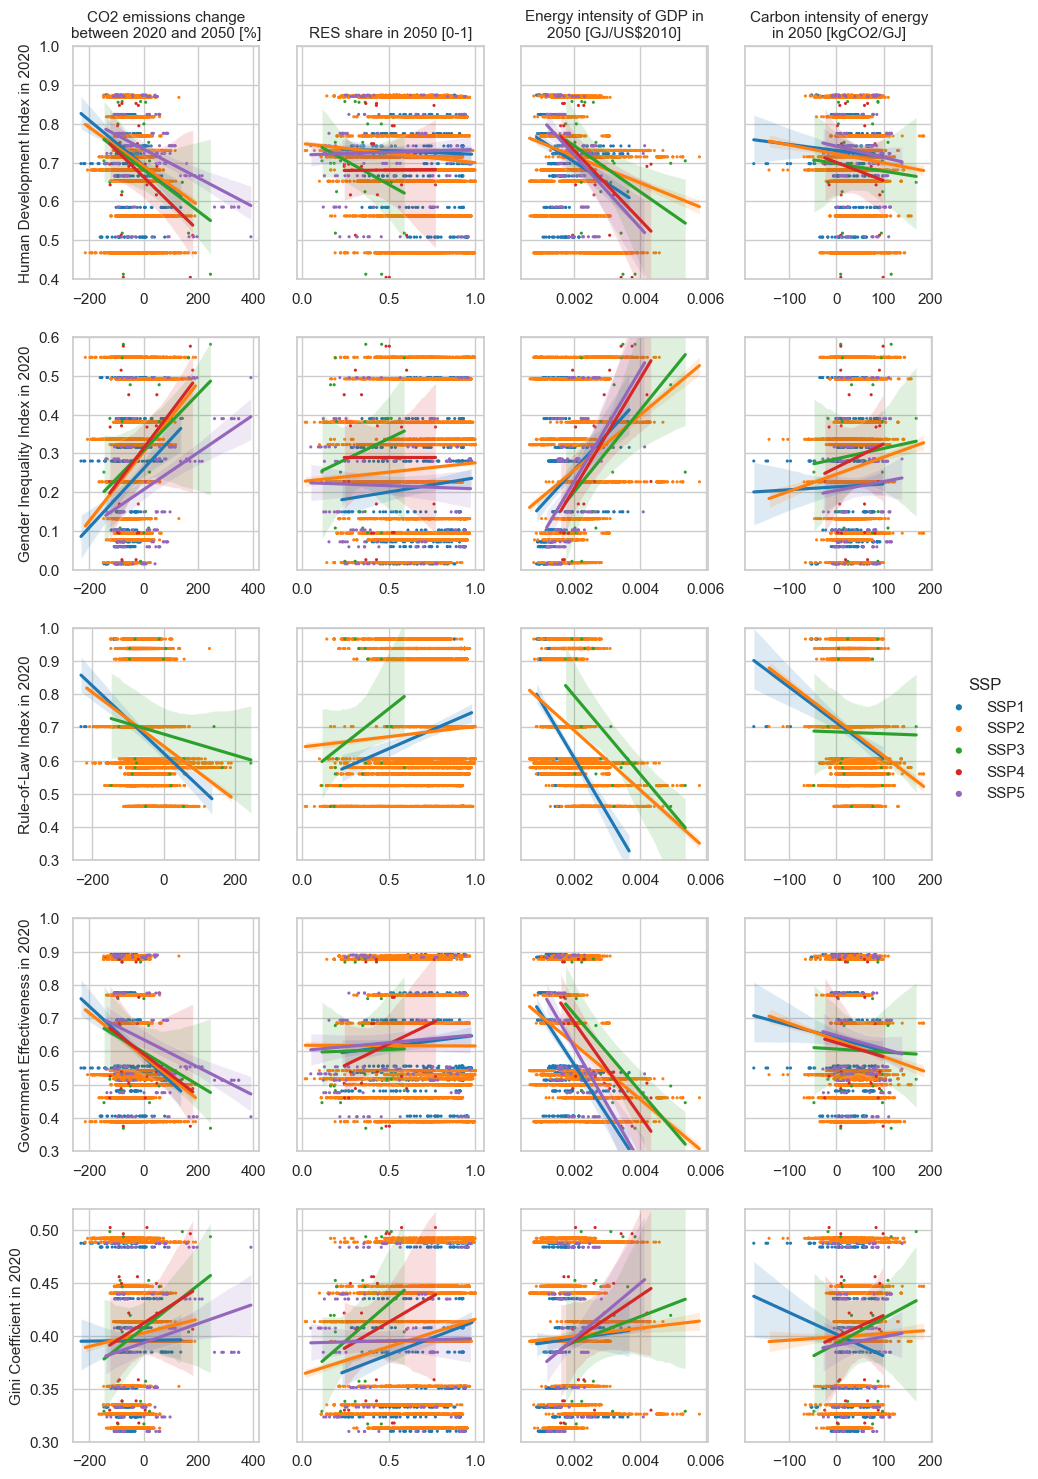

In [77]:
plot_assumptions_vs_impacts(
    df_merged,
    list_assumptions=[
        'Human Development Index [unweighted mean]',
        'Gender Inequality Index',
        'Rule-of-Law Index [unweighted mean]',
        'Governance Index|Government Effectiveness [unweighted mean]',
        'Gini Income Inequality Coefficient [unweighted mean|share]',
    ], 
    label_assumptions=[
        'Human Development Index',
        'Gender Inequality Index',
        'Rule-of-Law Index',
        'Government Effectiveness',
        'Gini Coefficient',
    ],
    ylims=[
        [0.4,1],
        [0,0.6],
        [0.3,1],
        [0.3,1],
        [0.3,0.52],
    ],
    file_name='manuscript_figures/Figure2.pdf'
)